# KNN Regression — Sales Dataset


Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
print('Libraries imported successfully!')

Libraries imported successfully!


 Load & Explore the Dataset

In [2]:
df = pd.read_csv('train_v9rqX0R.csv')
print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (8523, 12)

First 5 rows:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [4]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [5]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


Exploratory Data Analysis (EDA)

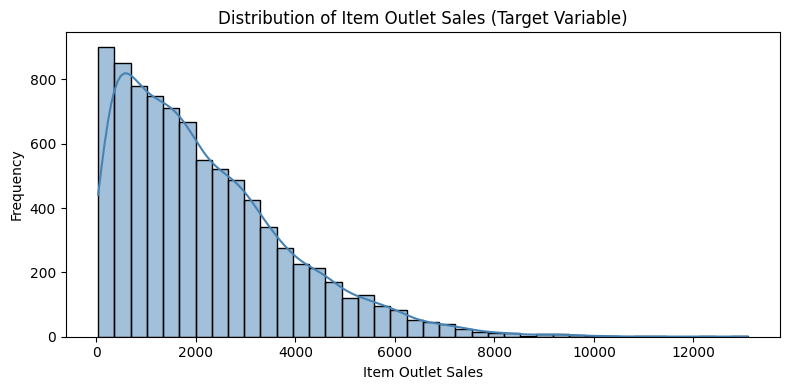

In [6]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
sns.histplot(df['Item_Outlet_Sales'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Item Outlet Sales (Target Variable)')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

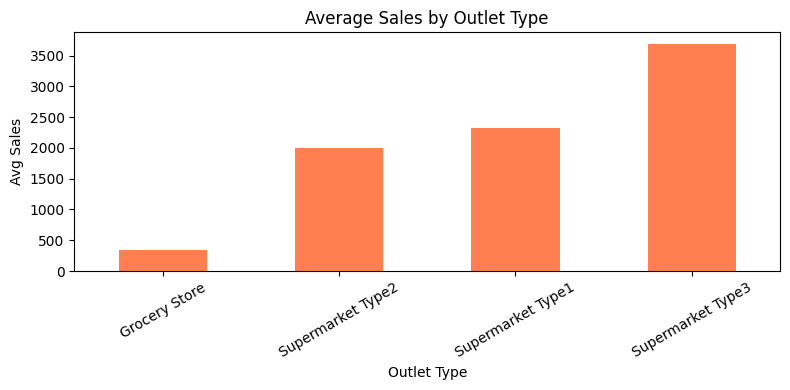

In [7]:
# Average sales by Outlet Type
plt.figure(figsize=(8, 4))
df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values().plot(kind='bar', color='coral')
plt.title('Average Sales by Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Avg Sales')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

 Data Preprocessing

In [8]:
# Handle missing values
mean_weight = df['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)

mode_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_size)

print('Missing values after handling:')
print(df.isnull().sum())

Missing values after handling:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


In [9]:
# Encode categorical columns
le = LabelEncoder()
cat_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
            'Outlet_Location_Type', 'Outlet_Type']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Drop identifier columns (not useful for prediction)
df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)

print('Shape after preprocessing:', df.shape)
df.head()

Shape after preprocessing: (8523, 10)


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,1,0.016047,4,249.8092,1999,1,0,1,3735.1380
1,5.92,2,0.019278,14,48.2692,2009,1,2,2,443.4228
2,17.50,1,0.016760,10,141.6180,1999,1,0,1,2097.2700
3,19.20,2,0.000000,6,182.0950,1998,1,2,0,732.3800
4,8.93,1,0.000000,9,53.8614,1987,0,2,1,994.7052


 Train-Test Split & Scaling

In [10]:
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Scale features (KNN is distance-based, scaling is critical)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 6818, Test size: 1705


: Initial KNN Model (K=5)

In [11]:
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)
pred = model.predict(X_test)

rmse = sqrt(mean_squared_error(y_test, pred))
print(f'RMSE (K=5): {rmse:.4f}')

RMSE (K=5): 1188.9286


Hyperparameter Tuning — Find Best K (Elbow Curve)

In [12]:
rmse_val = []
k_list   = []

for K in range(1, 26):
    knn = KNeighborsRegressor(n_neighbors=K)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error  = sqrt(mean_squared_error(y_test, pred_k))
    rmse_val.append(error)
    k_list.append(K)
    print(f'K={K:2d} | RMSE: {error:.4f}')

best_k    = k_list[rmse_val.index(min(rmse_val))]
best_rmse = min(rmse_val)
print(f'\nBest K = {best_k} | Lowest RMSE = {best_rmse:.4f}')

K= 1 | RMSE: 1512.0933
K= 2 | RMSE: 1332.3476
K= 3 | RMSE: 1246.2232
K= 4 | RMSE: 1222.6618
K= 5 | RMSE: 1188.9286
K= 6 | RMSE: 1179.1499
K= 7 | RMSE: 1168.5701
K= 8 | RMSE: 1159.5593
K= 9 | RMSE: 1154.0040
K=10 | RMSE: 1141.8987
K=11 | RMSE: 1138.2935
K=12 | RMSE: 1130.5753
K=13 | RMSE: 1129.2961
K=14 | RMSE: 1125.2151
K=15 | RMSE: 1123.7074
K=16 | RMSE: 1122.4448
K=17 | RMSE: 1121.4884
K=18 | RMSE: 1121.8856
K=19 | RMSE: 1122.6867
K=20 | RMSE: 1124.5258
K=21 | RMSE: 1123.5954
K=22 | RMSE: 1121.4027
K=23 | RMSE: 1121.7222
K=24 | RMSE: 1119.4725
K=25 | RMSE: 1119.2130

Best K = 25 | Lowest RMSE = 1119.2130


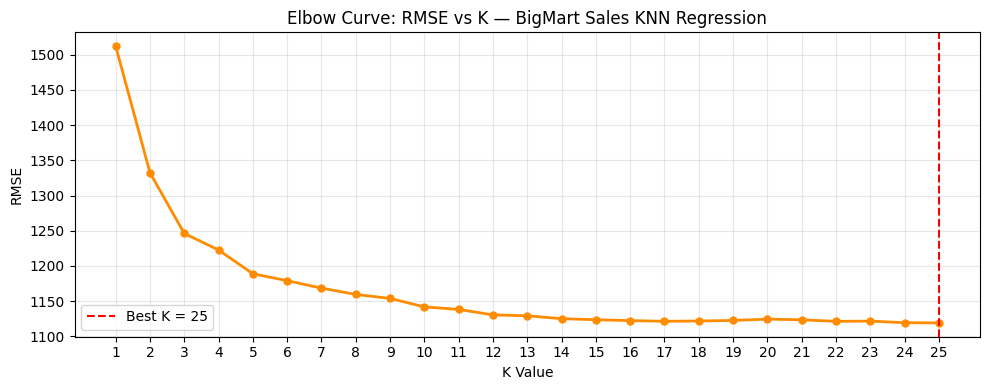

In [13]:
# Elbow Curve
plt.figure(figsize=(10, 4))
plt.plot(k_list, rmse_val, marker='o', color='darkorange', linewidth=2, markersize=5)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('K Value')
plt.ylabel('RMSE')
plt.title('Elbow Curve: RMSE vs K — BigMart Sales KNN Regression')
plt.xticks(k_list)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 Final Model Evaluation

In [14]:
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)

print(f'=== Final Model (K={best_k}) ===')
print(f'R² Score : {r2:.4f}')
print(f'MAE      : {mae:.4f}')
print(f'MSE      : {mse:.4f}')
print(f'RMSE     : {rmse:.4f}')

=== Final Model (K=25) ===
R² Score : 0.5720
MAE      : 811.9574
MSE      : 1252637.7630
RMSE     : 1119.2130


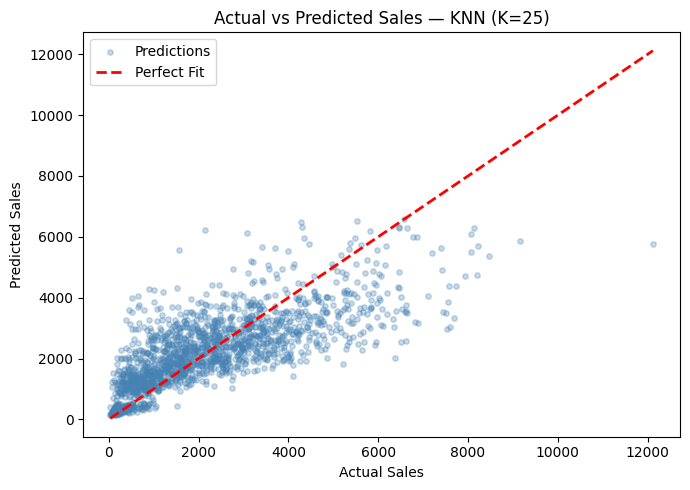

In [15]:
# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'Actual vs Predicted Sales — KNN (K={best_k})')
plt.legend()
plt.tight_layout()
plt.show()

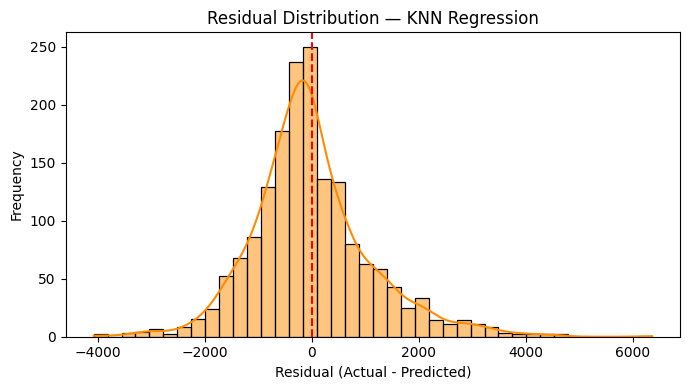

In [16]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=40, kde=True, color='darkorange')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution — KNN Regression')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()